# Figure 2 — Reproduction Notebook

In [1]:
from __future__ import annotations

import colorsys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import pdist

warnings.filterwarnings('ignore')

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['image.composite_image'] = False

# Data directory — relative to this notebook
BASE_DIR = "/data/wholebrain_crispr_atlas"
DATA_DIR = Path(f"{BASE_DIR}/supplementary_data")
print('Data directory:', DATA_DIR)
print('Files:', sorted(p.name for p in DATA_DIR.iterdir()))

Data directory: /data/wholebrain_crispr_atlas/supplementary_data
Files: ['Data S1. gRNA and custom Flex probes for 1,947 disease-associated risk genes.xlsx', 'Data S2. Animal metadata and fluorescent labeling efficiency by FACS.xlsx', "Data S3. gRNA depletion analysis across brain neighborhoods using Fisher's exact test & MAGeCK.xlsx", 'Data S4. Whole brain in vivo perturb-seq differentially expressed genes by Wilcoxon Rank Sum test.xlsx', 'Data S5. Pairwise energy distance & perturbation effect cosine similarity.xlsx', 'Data S6. Consolidated gene-level annotations for perturbation targets.xlsx', 'Data S7. DEG burden across perturbation & Enrichment of DEGs with disorder risk genes.xlsx', 'use_genes.txt']


---
Panels: **2E**, **2F**, **2H**

In [5]:
DEG_PATH = DATA_DIR / 'Data S4. Whole brain in vivo perturb-seq differentially expressed genes by Wilcoxon Rank Sum test.xlsx'
deg = pd.read_excel(DEG_PATH, header=1)
print(f'Rows: {len(deg):,}')
deg.head(3)

Rows: 137,461


,deg_names,scores,logfoldchanges,pvals,pvals_adj,group_name,gene_target,control_label,n_pert_matched,n_ctrl_matched
0,Snx29,4.606294,0.513303,4.099083e-06,0.068549,001 L5-6 IT Glut,Gnas,Non_target,72,4807
1,Josd2,5.707997,1.166415,1.143137e-08,0.000191,001 L5-6 IT Glut,Thap11,Non_target,70,4807
2,Thoc6,4.378333,2.735349,1.195908e-05,0.049998,001 L5-6 IT Glut,Thap11,Non_target,70,4807


### Figure 2E — Top-50 Perturbations by DEG Count (stacked barplot)

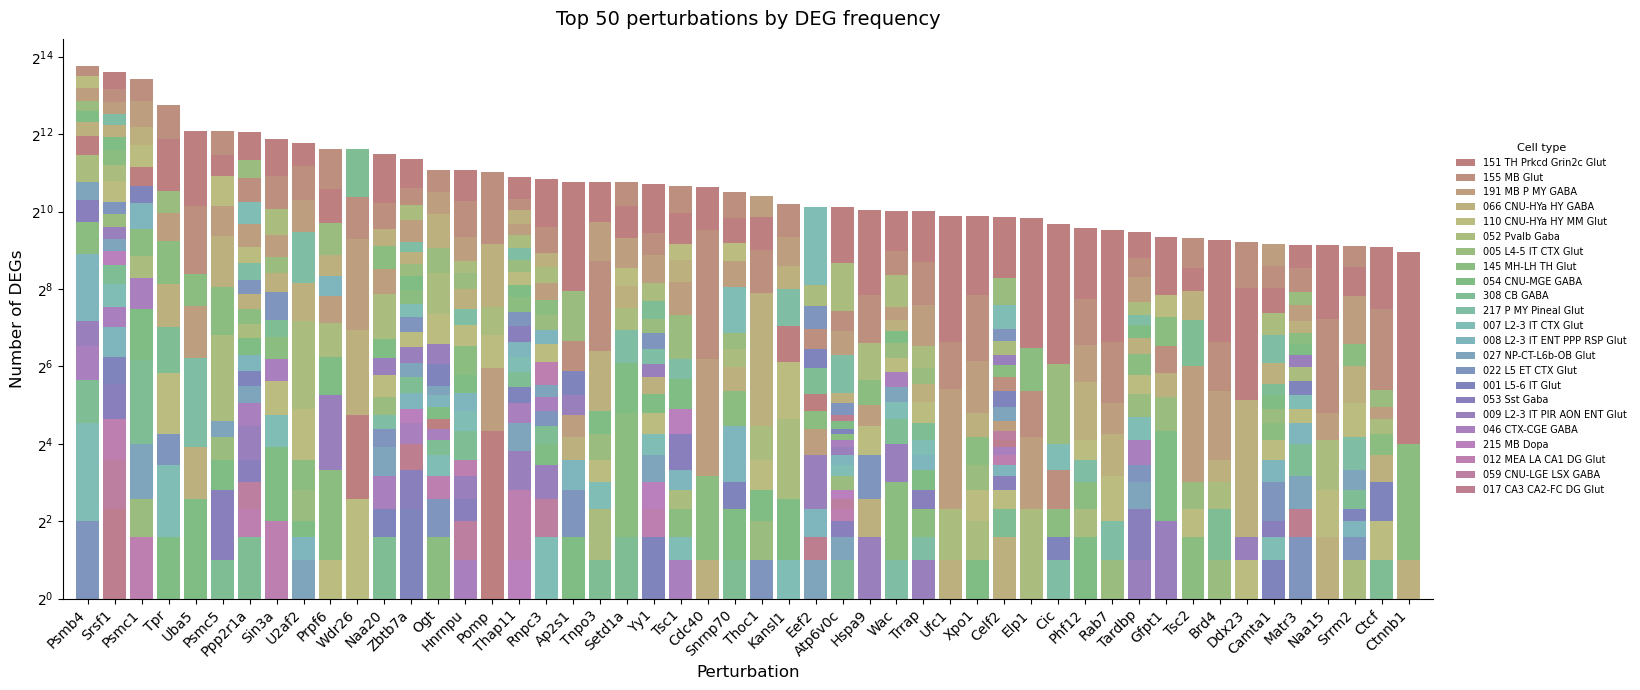

In [6]:
def plot_figure2E(df: pd.DataFrame, top_n: int = 50, title: str = 'Top 50 perturbations by DEG frequency') -> plt.Figure:
    counts = df.groupby(['gene_target', 'group_name']).size().rename('deg_n').reset_index()
    totals = counts.groupby('gene_target')['deg_n'].sum().sort_values(ascending=False)
    top_targets = totals.head(top_n).index.tolist()

    top = counts[counts['gene_target'].isin(top_targets)].copy()
    pivot = top.pivot(index='gene_target', columns='group_name', values='deg_n').fillna(0)
    pivot = pivot.reindex(index=top_targets)

    celltype_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
    pivot = pivot[celltype_order]

    n_ct = len(celltype_order)
    if n_ct == 1:
        colors = np.array([[0.60, 0.67, 0.76, 1.0]])
    else:
        hues = np.linspace(0, 1, n_ct, endpoint=False)
        colors = np.array([(*colorsys.hls_to_rgb(float(h), 0.62, 0.32), 1.0) for h in hues])

    color_by_ct = {ct: color for ct, color in zip(celltype_order, colors)}

    fig_w = max(14, top_n * 0.33)
    fig, ax = plt.subplots(figsize=(fig_w, 7.0), facecolor='white')
    ax.set_facecolor('white')

    for xi, target in enumerate(pivot.index):
        row = pivot.loc[target]
        row = row[row > 0].sort_values(ascending=True)
        bottom = 0.0
        for ct, val in row.items():
            ax.bar(xi, val, bottom=bottom, color=color_by_ct[ct], width=0.85, linewidth=0)
            bottom += float(val)

    ax.set_xticks(np.arange(len(pivot)))
    ax.set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=10)
    ax.set_xlabel('Perturbation', fontsize=12)
    ax.set_ylabel('Number of DEGs', fontsize=12)  # fixed: single ylabel
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_yscale('log', base=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.01)

    legend_handles = [Patch(facecolor=color_by_ct[ct], edgecolor='none', label=ct) for ct in celltype_order]
    ax.legend(
        handles=legend_handles, title='Cell type',
        loc='center left', bbox_to_anchor=(1.01, 0.5),
        frameon=False, fontsize=7, title_fontsize=8, ncol=1,
    )
    fig.tight_layout()
    return fig


fig2e = plot_figure2E(deg)
plt.show()

### Figure 2F — Pairwise Jaccard Similarity Heatmap

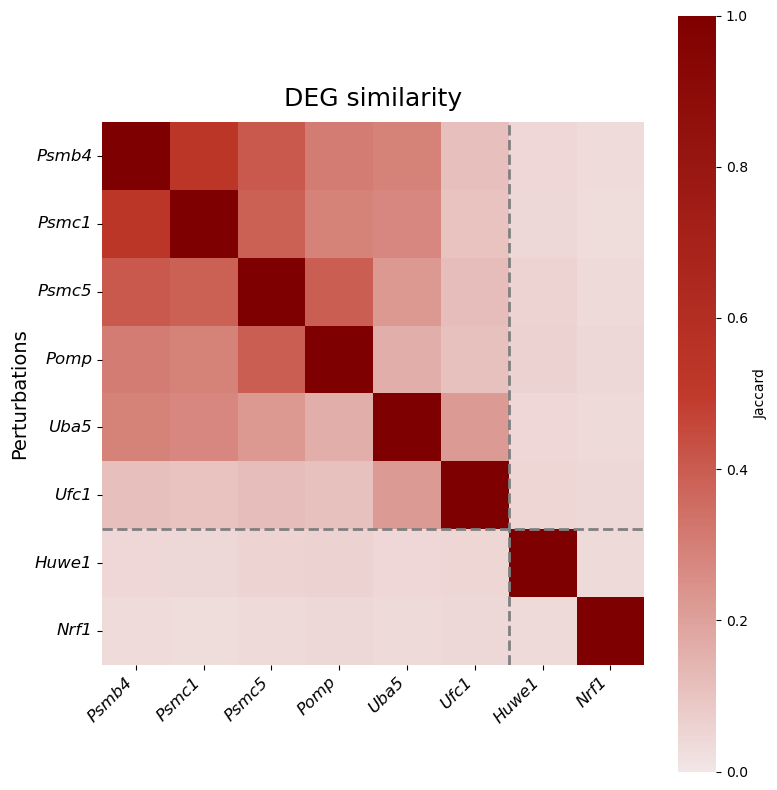

In [7]:
FIGURE2F_PERTURBATIONS = [
    'Psmb4', 'Psmc1', 'Psmc5', 'Pomp',
    'Uba5', 'Ufc1', 'Huwe1', 'Nrf1',
]

def compute_jaccard_matrix(df: pd.DataFrame, perturbations: list[str], padj_threshold: float = 0.1) -> pd.DataFrame:
    deg_sets: dict[str, set] = {}
    for p in perturbations:
        genes = set(
            df.loc[
                (df['gene_target'] == p) & (df['pvals_adj'] < padj_threshold),
                'deg_names',
            ].dropna().astype(str)
        )
        deg_sets[p] = genes

    n = len(perturbations)
    mat = np.zeros((n, n))
    for i, a in enumerate(perturbations):
        for j, b in enumerate(perturbations):
            inter = len(deg_sets[a] & deg_sets[b])
            union = len(deg_sets[a] | deg_sets[b])
            mat[i, j] = inter / union if union > 0 else 0.0

    return pd.DataFrame(mat, index=perturbations, columns=perturbations)


def plot_figure2F(
    df: pd.DataFrame,
    perturbations: list[str] = FIGURE2F_PERTURBATIONS,
    padj_threshold: float = 0.1,
    sep_after: int | None = None,
) -> plt.Figure:
    jaccard_df = compute_jaccard_matrix(df, perturbations, padj_threshold)

    cmap = LinearSegmentedColormap.from_list(
        'dark_red', ['#f2e6e6', '#c0392b', '#7f0000'],
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(
        jaccard_df, ax=ax, cmap=cmap, vmin=0, vmax=1,
        square=True, linewidths=0, cbar_kws={'label': 'Jaccard'},
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12, fontstyle='italic')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12, fontstyle='italic')
    ax.set_xlabel('')
    ax.set_ylabel('Perturbations', fontsize=14)

    sep = sep_after if sep_after is not None else len(perturbations) // 2
    ax.axhline(sep, color='gray', linestyle='--', linewidth=2)
    ax.axvline(sep, color='gray', linestyle='--', linewidth=2)

    ax.set_title('DEG similarity', fontsize=18, pad=12)
    fig.tight_layout()
    return fig

fig2f = plot_figure2F(deg, sep_after=6)
plt.show()

### Figure 2H — Tsc1 vs Tsc2 Shared-DEG Scatter (pathway-labeled)

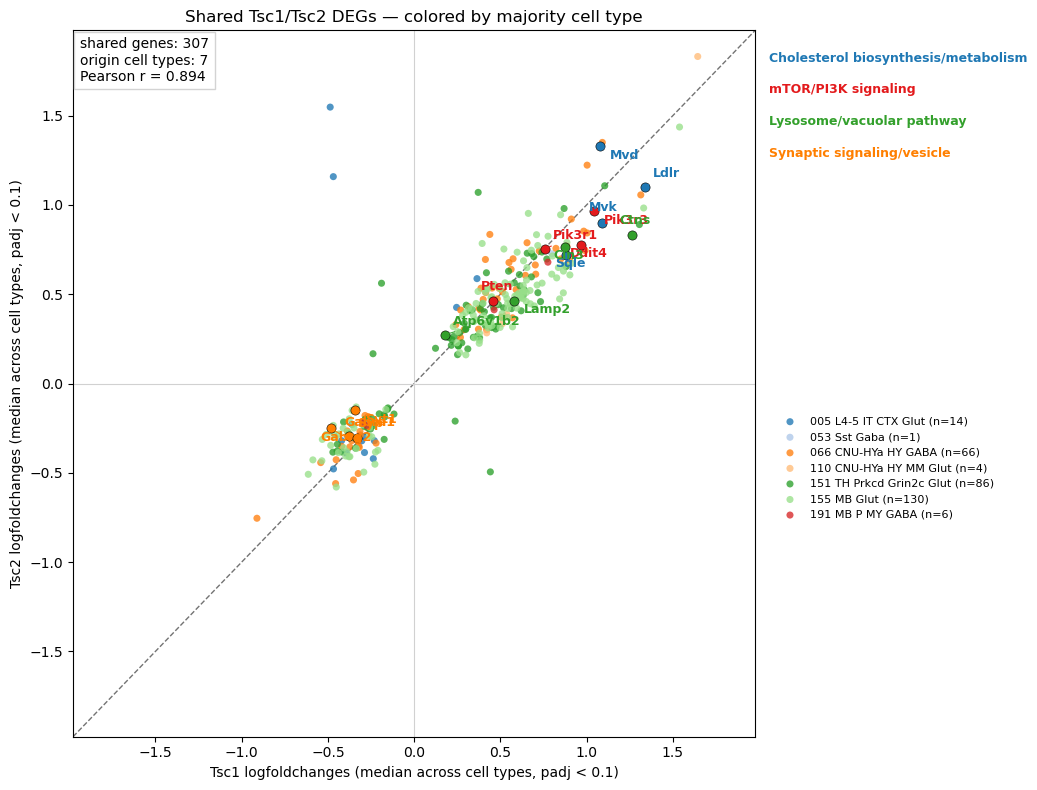

In [8]:
PATHWAY_GENES = {
    'Cholesterol biosynthesis/metabolism': ['Ldlr', 'Mvd', 'Mvk', 'Sqle'],
    'mTOR/PI3K signaling': ['Pik3r1', 'Pik3r3', 'Pten', 'Ddit4'],
    'Lysosome/vacuolar pathway': ['Atp6v1b2', 'Lamp2', 'Ctns', 'Cln3'],
    'Synaptic signaling/vesicle': ['Syp', 'Syt1', 'Gabra1', 'Gabrg2'],
}
PATHWAY_COLORS = {
    'Cholesterol biosynthesis/metabolism': '#1f78b4',
    'mTOR/PI3K signaling': '#e31a1c',
    'Lysosome/vacuolar pathway': '#33a02c',
    'Synaptic signaling/vesicle': '#ff7f00',
}


def build_tsc_points(df: pd.DataFrame, padj_threshold: float = 0.1) -> pd.DataFrame:
    dff = df[
        (df['pvals_adj'] < padj_threshold) & (df['gene_target'].isin(['Tsc1', 'Tsc2']))
    ].copy()
    t1 = dff[dff['gene_target'] == 'Tsc1']
    t2 = dff[dff['gene_target'] == 'Tsc2']
    shared = sorted(set(t1['deg_names'].astype(str)) & set(t2['deg_names'].astype(str)))

    rows = []
    for gene in shared:
        g1 = t1[t1['deg_names'] == gene]
        g2 = t2[t2['deg_names'] == gene]
        x = float(g1['logfoldchanges'].median())
        y = float(g2['logfoldchanges'].median())
        # majority cell type
        ct_counts = pd.concat([g1[['group_name']], g2[['group_name']]]).value_counts()
        origin = str(ct_counts.index[0][0]) if len(ct_counts) else 'NA'
        rows.append({'gene': gene, 'lfc_tsc1': x, 'lfc_tsc2': y, 'origin_celltype': origin})
    return pd.DataFrame(rows)


def plot_figure2H(df: pd.DataFrame, padj_threshold: float = 0.1) -> plt.Figure:
    points = build_tsc_points(df, padj_threshold)
    if points.empty:
        raise ValueError('No shared Tsc1/Tsc2 genes found.')

    celltypes = sorted(points['origin_celltype'].unique())
    cmap = plt.get_cmap('tab20')
    ct_colors = {ct: cmap(i % 20) for i, ct in enumerate(celltypes)}

    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    for ct in celltypes:
        d = points[points['origin_celltype'] == ct]
        ax.scatter(
            d['lfc_tsc1'], d['lfc_tsc2'],
            s=26, alpha=0.78, c=[ct_colors[ct]],
            label=f'{ct} (n={len(d)})', edgecolors='none', zorder=2,
        )

    vals = np.concatenate([points['lfc_tsc1'].values, points['lfc_tsc2'].values])
    lim = max(0.5, float(np.nanmax(np.abs(vals))) * 1.08)
    ax.plot([-lim, lim], [-lim, lim], color='0.45', lw=1.0, ls='--', zorder=1)
    ax.axhline(0, color='0.82', lw=0.8, zorder=1)
    ax.axvline(0, color='0.82', lw=0.8, zorder=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Tsc1 logfoldchanges (median across cell types, padj < 0.1)')
    ax.set_ylabel('Tsc2 logfoldchanges (median across cell types, padj < 0.1)')
    ax.set_title('Shared Tsc1/Tsc2 DEGs — colored by majority cell type')

    # Annotate pathway genes
    offsets = [(6, 7), (7, -9), (-9, 8), (-8, -9)]
    for pathway, genes in PATHWAY_GENES.items():
        color = PATHWAY_COLORS[pathway]
        for i, gene in enumerate(genes):
            hit = points[points['gene'] == gene]
            if hit.empty:
                continue
            r = hit.iloc[0]
            x, y = float(r['lfc_tsc1']), float(r['lfc_tsc2'])
            ax.scatter([x], [y], s=44, c=[color], edgecolors='black', linewidths=0.4, zorder=4)
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                gene, xy=(x, y), xytext=(dx, dy), textcoords='offset points',
                fontsize=9, color=color, weight='bold',
                arrowprops={'arrowstyle': '-', 'color': color, 'lw': 0.8, 'alpha': 0.9},
                zorder=5,
            )

    r_val = np.corrcoef(points['lfc_tsc1'], points['lfc_tsc2'])[0, 1]
    ax.text(
        0.01, 0.99,
        f'shared genes: {len(points)}\norigin cell types: {len(celltypes)}\nPearson r = {r_val:.3f}',
        transform=ax.transAxes, ha='left', va='top', fontsize=10,
        bbox={'facecolor': 'white', 'alpha': 0.86, 'edgecolor': '0.8'},
    )

    # Pathway legend
    y0 = 0.97
    for i, pathway in enumerate(PATHWAY_GENES):
        ax.text(
            1.02, y0 - 0.045 * i, pathway,
            transform=ax.transAxes, ha='left', va='top',
            fontsize=9, color=PATHWAY_COLORS[pathway], weight='bold',
        )

    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.38), frameon=False, fontsize=8)
    fig.tight_layout()
    return fig


fig2h = plot_figure2H(deg)
plt.show()

---
Panel: **2G**

In [9]:
# Build shared6_deg_lfc_padj0.1_matrix from deg (same format as precomputed TSV)
# Rows = 6 perturbations, columns = genes significant in all 6 at padj < 0.1, values = median LFC
SHARED6_PERTURBATIONS = ["Pomp", "Psmc1", "Psmb4", "Psmc5", "Uba5", "Ufc1"]
PADJ_THRESHOLD = 0.1
gene_col = "names" if "names" in deg.columns else "deg_names"

deg_sig = deg.loc[deg["pvals_adj"] < PADJ_THRESHOLD].copy()
deg_sig = deg_sig[deg_sig["gene_target"].isin(SHARED6_PERTURBATIONS)]
deg_sig[gene_col] = deg_sig[gene_col].astype(str)

# Genes that appear (significant) in all 6 perturbations
n_perts_per_gene = deg_sig.groupby(gene_col)["gene_target"].nunique()
shared_genes = sorted(n_perts_per_gene[n_perts_per_gene == 6].index.tolist())

deg_shared = deg_sig[deg_sig[gene_col].isin(shared_genes)]
agg = deg_shared.groupby(["gene_target", gene_col], as_index=False)["logfoldchanges"].median()
lfc_matrix = agg.pivot(index="gene_target", columns=gene_col, values="logfoldchanges")
lfc_matrix = lfc_matrix.reindex(index=SHARED6_PERTURBATIONS)[shared_genes]

# Sort columns by mean LFC across all 6 perturbations (descending)
col_order = lfc_matrix.mean(axis=0).sort_values(ascending=False).index.tolist()
lfc_matrix = lfc_matrix[col_order]

lfc_matrix.iloc[:, :5]

deg_names,Bid,Gadd45g,Ddit3,Aen,Tmem251
gene_target,,,,,
Pomp,1.504632,1.963064,1.674192,1.538373,1.661639
Psmc1,1.812241,1.734745,1.987405,1.921844,1.659618
Psmb4,1.606512,2.037485,1.443645,1.877114,1.923785
Psmc5,1.384248,1.489146,1.352346,1.591485,1.345844
Uba5,1.549228,0.746137,0.966427,0.491105,0.626607
Ufc1,1.789220,0.854131,0.922637,0.608021,0.704694


### Figure 2G — Shared DEG LFC Heatmap with Labeled Marker Genes


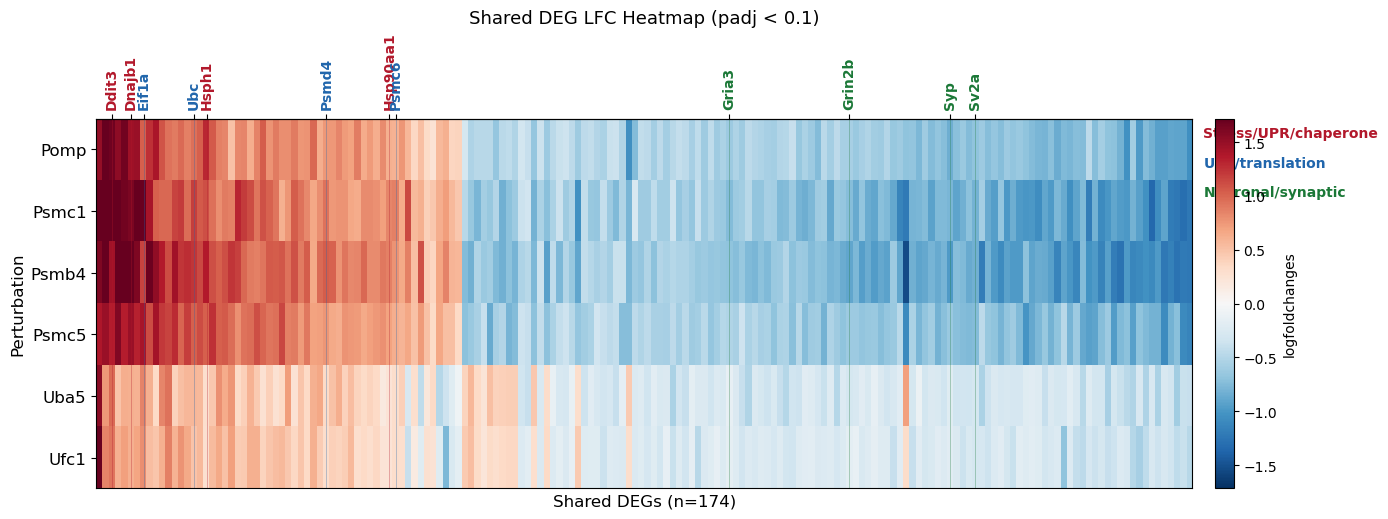

In [10]:
MARKER_GROUPS = {
    'Stress/UPR/chaperone': ['Ddit3', 'Dnajb1', 'Hsph1', 'Hsp90aa1'],
    'UPS/translation': ['Psmc6', 'Psmd4', 'Ubc', 'Eif1a'],
    'Neuronal/synaptic': ['Grin2b', 'Gria3', 'Syp', 'Sv2a'],
}
GROUP_COLORS = {
    'Stress/UPR/chaperone': '#b2182b',
    'UPS/translation': '#2166ac',
    'Neuronal/synaptic': '#1b7837',
}


def plot_figure2G(
    m: pd.DataFrame,
    marker_groups: dict = MARKER_GROUPS,
    group_colors: dict = GROUP_COLORS,
) -> plt.Figure:
    vals = m.to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]
    vmax = float(np.quantile(np.abs(finite), 0.99)) if finite.size else 1.0
    vmax = max(vmax, 0.5)

    n_genes = m.shape[1]
    fig_w = min(42, max(14, n_genes * 0.05))

    fig, ax = plt.subplots(figsize=(fig_w, 5.3))
    im = ax.imshow(m.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

    ax.set_yticks(np.arange(len(m.index)))
    ax.set_yticklabels(m.index, fontsize=12)
    ax.set_ylabel('Perturbation', fontsize=12)
    ax.set_xticks([])
    ax.set_xlabel(f'Shared DEGs (n={n_genes})', fontsize=12)
    ax.set_title('Shared DEG LFC Heatmap (padj < 0.1)', fontsize=13)

    # Label selected marker genes on top axis
    label_positions, label_names, label_colors, missing = [], [], [], []
    for group, genes in marker_groups.items():
        color = group_colors[group]
        for g in genes:
            if g in m.columns:
                pos = int(np.where(m.columns == g)[0][0])
                label_positions.append(pos)
                label_names.append(g)
                label_colors.append(color)
            else:
                missing.append(g)

    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(label_positions)
    ax_top.set_xticklabels(label_names, rotation=90, fontsize=10, va='bottom')
    for tick, color in zip(ax_top.get_xticklabels(), label_colors):
        tick.set_color(color)
        tick.set_fontweight('bold')

    for pos, color in zip(label_positions, label_colors):
        ax.axvline(pos, color=color, lw=0.5, alpha=0.45)

    cbar = fig.colorbar(im, ax=ax, fraction=0.020, pad=0.02)
    cbar.set_label('logfoldchanges')

    legend_x = 1.01
    y0 = 0.98
    dy = 0.08
    for i, group in enumerate(marker_groups):
        ax.text(
            legend_x, y0 - i * dy, group,
            color=group_colors[group], fontsize=10,
            transform=ax.transAxes, ha='left', va='top', fontweight='bold',
        )

    if missing:
        print(f'Missing marker genes (not in matrix): {missing}')

    fig.tight_layout()
    return fig


fig2g = plot_figure2G(lfc_matrix)
plt.show()

---

Panel: **2I**

In [11]:
df_raw = pd.read_parquet(f"{BASE_DIR}/analysis/wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet")

In [15]:
# Parameters for Figure 2I
CELLTYPE_2I  = '151 TH Prkcd Grin2c Glut'
PERTS_2I     = ['Smarcb1', 'Smarcc2', 'Arid2', 'Arid1a']
PADJ_2I      = 0.1
MIN_SHARED_2I = 2

raw_2i = df_raw[
    (df_raw['group_name'] == CELLTYPE_2I) & 
    (df_raw['gene_target'].isin(PERTS_2I))
][['names', 'gene_target', 'logfoldchanges', 'pvals_adj']]

print(f'Loaded {len(raw_2i):,} rows for Figure 2I')
raw_2i.head(3)

Loaded 69,036 rows for Figure 2I


,names,gene_target,logfoldchanges,pvals_adj
573949829,Clstn2,Arid1a,0.385385,0.000005
573949830,Ndrg4,Arid1a,0.109453,0.004631
573949831,Slc25a23,Arid1a,0.240324,0.005965


### Figure 2I — SWI/SNF Clustered Heatmap (boxed = significant)


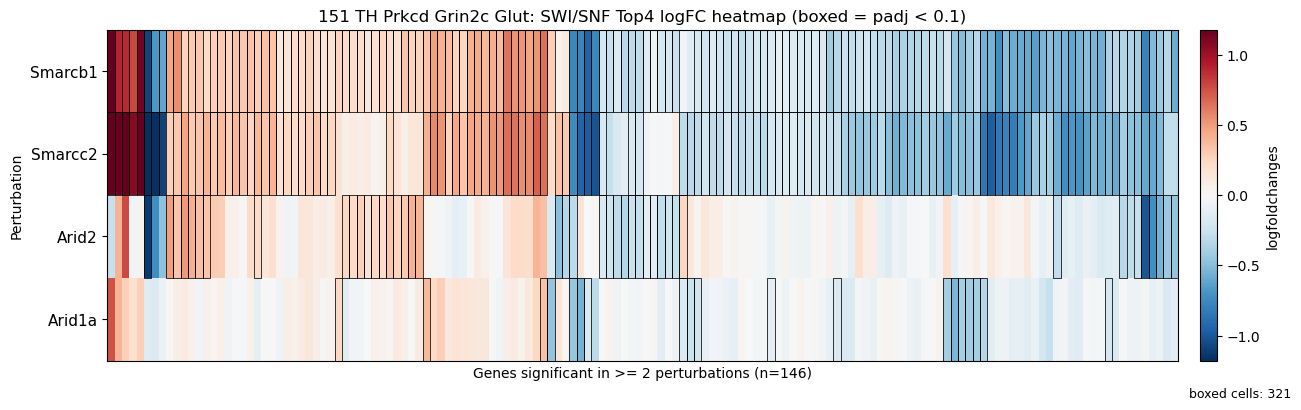

In [17]:
def cluster_order(values: np.ndarray) -> np.ndarray:
    if values.shape[0] <= 1:
        return np.arange(values.shape[0])
    dist = pdist(values, metric='euclidean')
    Z = linkage(dist, method='average')
    return leaves_list(Z)


def plot_figure2I(
    raw: pd.DataFrame,
    perturbations: list[str] = PERTS_2I,
    celltype: str = CELLTYPE_2I,
    padj_threshold: float = PADJ_2I,
    min_shared: int = MIN_SHARED_2I,
    label_genes: bool = False,
) -> plt.Figure:
    # Defensive aggregation for duplicates
    agg = (
        raw.groupby(['gene_target', 'names'], as_index=False)
        .agg(logfoldchanges=('logfoldchanges', 'median'), pvals_adj=('pvals_adj', 'min'))
    )

    lfc_mat  = agg.pivot(index='gene_target', columns='names', values='logfoldchanges')
    padj_mat = agg.pivot(index='gene_target', columns='names', values='pvals_adj')
    lfc_mat  = lfc_mat.reindex(index=perturbations)
    padj_mat = padj_mat.reindex(index=perturbations)

    sig_mat = padj_mat < padj_threshold
    keep_genes = sig_mat.sum(axis=0)
    keep_genes = keep_genes[keep_genes >= min_shared].index.tolist()
    keep_genes = sorted(keep_genes)

    if not keep_genes:
        raise ValueError(f'No genes pass min_shared={min_shared}.')

    lfc_sub  = lfc_mat[keep_genes].fillna(0.0)
    sig_sub  = sig_mat[keep_genes].fillna(False)
    shared_counts = sig_mat.sum(axis=0)[keep_genes]

    row_order = cluster_order(lfc_sub.values)
    col_order = cluster_order(lfc_sub.T.values)
    lfc_cl  = lfc_sub.iloc[row_order, col_order]
    sig_cl  = sig_sub.iloc[row_order, col_order]
    shared_cl = shared_counts.iloc[col_order]

    vals = lfc_cl.values
    vmax = float(np.quantile(np.abs(vals), 0.99))
    vmax = max(vmax, 0.5)

    fig_w = max(12, min(50, 0.09 * lfc_cl.shape[1]))
    fig_h = 6.0 if label_genes else 4.2
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    n_rows, n_cols = lfc_cl.shape
    x_edges = np.arange(n_cols + 1) - 0.5
    y_edges = np.arange(n_rows + 1) - 0.5
    im = ax.pcolormesh(
        x_edges, y_edges, lfc_cl.values,
        cmap='RdBu_r', vmin=-vmax, vmax=vmax,
        shading='flat', antialiased=False,
    )
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)

    ax.set_yticks(np.arange(lfc_cl.shape[0]))
    ax.set_yticklabels(lfc_cl.index, fontsize=11)
    if label_genes:
        ax.set_xticks(np.arange(lfc_cl.shape[1]))
        ax.set_xticklabels(lfc_cl.columns, rotation=90, fontsize=5)
    else:
        ax.set_xticks([])
    ax.set_ylabel('Perturbation')
    ax.set_xlabel(f'Genes significant in >= {min_shared} perturbations (n={lfc_cl.shape[1]})')
    ax.set_title(f'{celltype}: SWI/SNF Top4 logFC heatmap (boxed = padj < {padj_threshold:g})')

    n_box = 0
    for i in range(sig_cl.shape[0]):
        for j in range(sig_cl.shape[1]):
            if bool(sig_cl.iat[i, j]):
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor='black', linewidth=0.55,
                ))
                n_box += 1

    cbar = fig.colorbar(im, ax=ax, fraction=0.020, pad=0.02)
    cbar.set_label('logfoldchanges')
    ax.text(
        1.01, -0.08, f'boxed cells: {n_box}',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
    )

    fig.tight_layout()
    return fig


fig2i = plot_figure2I(raw_2i)
plt.show()